# Taller: Redes Neuronales en la Practica
## PyTorch y JAX — clasificacion desde cero

**Mineria de Datos · Diego Villalba · Facultad de Ciencias, UNAM**

---

Este notebook acompana la clase presencial. Sigan las instrucciones del instructor y completen los bloques marcados con `# TODO`.

**Prerequisito:** ya conocen `sklearn.neural_network.MLPClassifier`.  
Hoy abriremos esa caja negra implementando el mismo clasificador en PyTorch y JAX.

### Instalacion rapida (si usan Colab)
```
!pip install jax optax flax --quiet
```

In [41]:
# ── Imports globales ─────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.size"] = 12

SEED = 42
np.random.seed(SEED)

print("Entorno listo.")

Entorno listo.


# Dataset: Make Moons
Comenzaremos con el ejemplo clásico de make moons 

Text(0.5, 1.0, 'Make Moons Dataset')

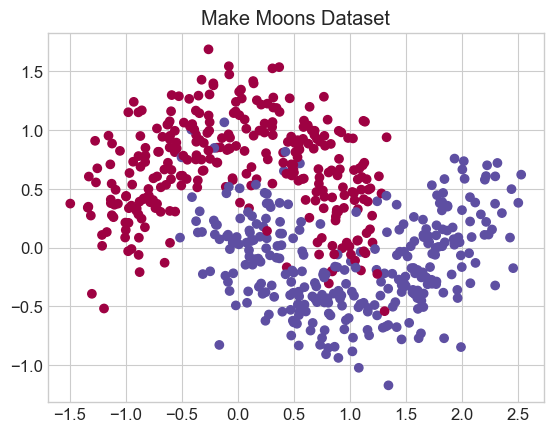

In [42]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=600, noise=0.25, random_state=SEED)

plt.scatter(X[:,0],X[:,1], c = y, cmap=plt.cm.Spectral)
plt.title("Make Moons Dataset")


---
## Parte 0 — Repaso: sklearn MLPClassifier

Antes de pasar a PyTorch, veamos el punto de partida. Este codigo ya lo conocen.

In [43]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=y
)

clf_sk = MLPClassifier(hidden_layer_sizes=(32, 32), 
                       max_iter=500, 
                       random_state=SEED
                       )
clf_sk.fit(X_train, y_train)
print(f"sklearn MLP  |  Val accuracy: {clf_sk.score(X_val, y_val):.3f}")

sklearn MLP  |  Val accuracy: 0.933


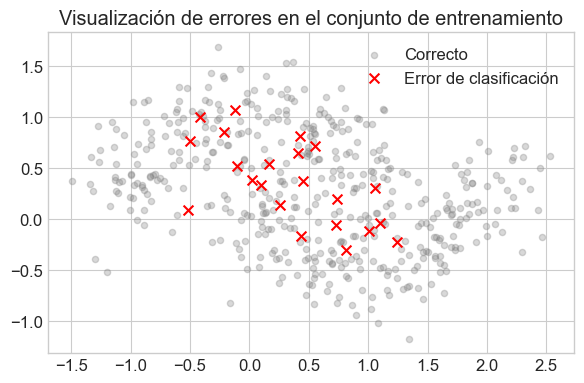

In [44]:

y_pred = clf_sk.predict(X_train)
errores = (y_pred != y_train)


fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_train[~errores, 0], X_train[~errores, 1], 
           c="gray", alpha=0.3, label="Correcto", s=20)
ax.scatter(X_train[errores, 0], X_train[errores, 1], 
           c="red", marker="x", label="Error de clasificación", s=50)

ax.set_title("Visualización de errores en el conjunto de entrenamiento")
ax.legend()
plt.tight_layout()
plt.show()

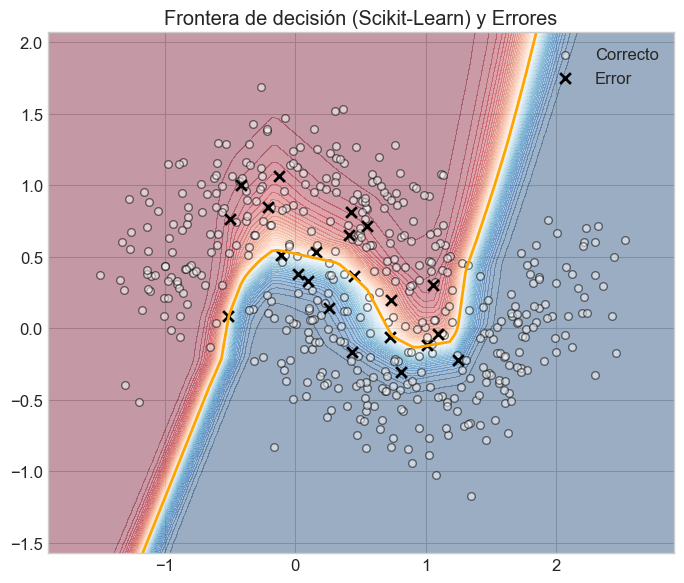

In [55]:
# 1. Definir la malla (igual que antes)
h = 0.04
x0_min, x0_max = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
x1_min, x1_max = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h), np.arange(x1_min, x1_max, h))

# 2. Predecir probabilidades para el fondo
# predict_proba devuelve [prob_clase0, prob_clase1], usamos [:, 1] para la clase 1
Z = clf_sk.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# 3. Predicciones reales para marcar errores
y_pred = clf_sk.predict(X_train)
errores = (y_pred != y_train)

# 4. Graficar
fig, ax = plt.subplots(figsize=(7, 6))

# Frontera de decisión de fondo
ax.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.4)
ax.contour(xx, yy, Z, levels=[0.5], colors="orange", linewidths=2)

# Puntos correctos
ax.scatter(X_train[~errores, 0], X_train[~errores, 1], 
           c="white", edgecolors="black", s=30, alpha=0.5, label="Correcto")

# Errores (X rojas)
ax.scatter(X_train[errores, 0], X_train[errores, 1], 
           c="black", marker="x", s=60, linewidths=2, label="Error")

ax.set_title("Frontera de decisión (Scikit-Learn) y Errores")
ax.legend()
plt.tight_layout()
plt.show()

In [45]:
sample = X_val[1].reshape(1, -1)
clf_sk.predict(sample)

array([0])

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, y_pred)
print(cm)

[[232   8]
 [ 14 226]]


**Pregunta de discusion:** sklearn entrena y produce resultados, pero no tenemos acceso a:
- Las curvas de perdida epoch a epoch
- El grafo computacional
- La posibilidad de definir arquitecturas personalizadas (CNN, RNN, Transformer)

Para eso necesitamos PyTorch o JAX.

---
## Parte 1 — PyTorch

### 1.1 Preparacion de datos

In [47]:
import torch
import torch.nn as nn

# Convertir arrays de numpy a tensores de PyTorch
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # shape: (N, 1)
X_vl = torch.tensor(X_val,   dtype=torch.float32)
y_vl = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

print(f"X_tr: {X_tr.shape}  y_tr: {y_tr.shape}")
print(f"X_vl: {X_vl.shape}  y_vl: {y_vl.shape}")

X_tr: torch.Size([480, 2])  y_tr: torch.Size([480, 1])
X_vl: torch.Size([120, 2])  y_vl: torch.Size([120, 1])


### 1.2 Definir el modelo

En PyTorch, todo modelo es una subclase de `nn.Module`.  
Debe implementar el metodo `forward(self, x)` que describe el computo.

Arquitectura: **[2 → 32 → 32 → 1]** con activaciones ReLU y una salida lineal (logit).

In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            # TODO: Completar la arquitectura
            # Capa 1: Linear(2, 32) + ReLU
            # Capa 2: Linear(32, 32) + ReLU
            # Capa de salida: Linear(32, 1)  <- sin activacion, produce logit
        )

    def forward(self, x):
        # TODO: retornar self.red(x)
        pass


# Instanciar y revisar
torch.manual_seed(SEED)
modelo = MLP()
print(modelo)
print(f"\nTotal de parametros: {sum(p.numel() for p in modelo.parameters()):,}")

MLP(
  (red): Sequential()
)

Total de parametros: 0


In [6]:
# Solucion (desplegar solo si es necesario)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

torch.manual_seed(SEED)
modelo = MLP()
print(f"Parametros: {sum(p.numel() for p in modelo.parameters()):,}")

Parametros: 1,185


### 1.3 El ciclo de entrenamiento

El ciclo de PyTorch siempre tiene el mismo patron de **5 pasos**:

```
1. optimizer.zero_grad()   ← limpiar gradientes acumulados
2. logits = modelo(X)      ← forward pass
3. loss = criterio(logits) ← calcular perdida
4. loss.backward()         ← backward pass (calcula gradientes)
5. optimizer.step()        ← actualizar pesos
```

> **Por que `BCEWithLogitsLoss` y no `BCELoss`?**  
> `BCEWithLogitsLoss` aplica la sigmoide internamente usando el truco log-sum-exp, que es numericamente mas estable que calcular `sigmoid(logit)` primero y luego `log`.

In [ ]:
torch.manual_seed(SEED)
modelo   = MLP()
opt      = torch.optim.Adam(modelo.parameters(), lr=0.01)
criterio = nn.BCEWithLogitsLoss()

hist_pt = {"tr_loss": [], "vl_loss": [], "tr_acc": [], "vl_acc": []}

for epoch in range(300):
    # --- Entrenamiento ---
    modelo.train()

    # TODO: completar los 5 pasos del ciclo
    # 1. zero_grad
    # 2. forward
    # 3. calcular perdida
    # 4. backward
    # 5. step

    # --- Evaluacion sin gradientes ---
    with torch.no_grad():
        modelo.eval()
        # TODO: calcular vl_loss, tr_acc, vl_acc
        # Hint: (torch.sigmoid(logits) >= 0.5).float() da las predicciones binarias
        pass

print(f"Epoch 300 | Val loss: {hist_pt['vl_loss'][-1]:.4f} | Val acc: {hist_pt['vl_acc'][-1]:.3f}")

In [48]:
# Solucion
torch.manual_seed(SEED)
modelo   = MLP()
opt      = torch.optim.Adam(modelo.parameters(), lr=0.01)
criterio = nn.BCEWithLogitsLoss()

hist_pt = {"tr_loss": [], "vl_loss": [], "tr_acc": [], "vl_acc": []}

for epoch in range(300):
    modelo.train()
    opt.zero_grad()
    logits = modelo(X_tr)
    loss   = criterio(logits, y_tr)
    loss.backward()
    opt.step()

    with torch.no_grad():
        modelo.eval()
        vl_logits = modelo(X_vl)
        vl_loss   = criterio(vl_logits, y_vl).item()
        tr_acc    = (torch.sigmoid(logits) >= 0.5).float().eq(y_tr).float().mean().item()
        vl_acc    = (torch.sigmoid(vl_logits) >= 0.5).float().eq(y_vl).float().mean().item()

    hist_pt["tr_loss"].append(loss.item())
    hist_pt["vl_loss"].append(vl_loss)
    hist_pt["tr_acc"].append(tr_acc)
    hist_pt["vl_acc"].append(vl_acc)

print(f"Val accuracy final: {hist_pt['vl_acc'][-1]:.3f}")

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.
Val accuracy final: 0.925


### 1.4 Visualizacion de resultados

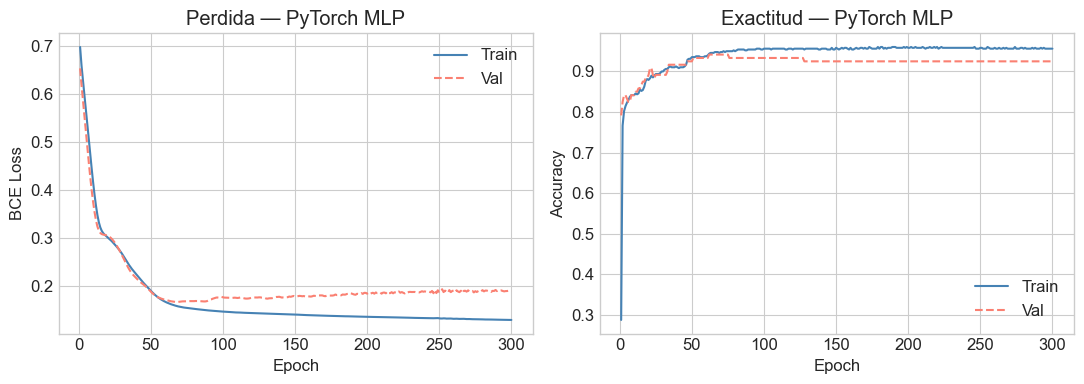

In [49]:
epochs = range(1, 301)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs, hist_pt["tr_loss"], label="Train", color="steelblue")
ax1.plot(epochs, hist_pt["vl_loss"], label="Val",   color="salmon", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("Perdida — PyTorch MLP")
ax1.legend()

ax2.plot(epochs, hist_pt["tr_acc"], label="Train", color="steelblue")
ax2.plot(epochs, hist_pt["vl_acc"], label="Val",   color="salmon", linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Exactitud — PyTorch MLP")
ax2.legend()

plt.tight_layout()
plt.show()

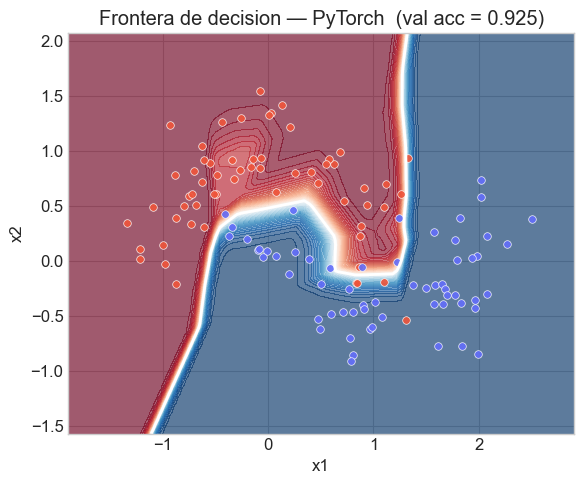

In [10]:
# Frontera de decision
h = 0.04
x0_min, x0_max = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
x1_min, x1_max = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    modelo.eval()
    prob = torch.sigmoid(modelo(grid)).numpy().reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, prob, levels=50, cmap="RdBu", alpha=0.65)
ax.contour(xx, yy, prob, levels=[0.5], colors="white", linewidths=2)
for cls, color in [(0, "#EF553B"), (1, "#636EFA")]:
    mask = y_val == cls
    ax.scatter(X_val[mask, 0], X_val[mask, 1], c=color, edgecolors="white",
               linewidths=0.5, s=30, alpha=0.9)
ax.set_title(f"Frontera de decision — PyTorch  (val acc = {hist_pt['vl_acc'][-1]:.3f})")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.tight_layout()
plt.show()

In [67]:
# 1. Obtener los logits del modelo
logits = modelo(X_vl)

# 2. Convertir a probabilidades (si usaste BCEWithLogitsLoss)
probabilidades = torch.sigmoid(logits)

# 3. Aplicar el umbral: mayor a 0.5 es clase 1, menor es clase 0
predicciones = (probabilidades >= 0.5).int()

# 4. Ahora sí, calcular la matriz de confusión
cm_pytorch = confusion_matrix(y_vl.detach().numpy(), predicciones.detach().numpy())
print(cm_pytorch)

[[55  5]
 [ 4 56]]


---
## Parte 2 — JAX

### El cambio de paradigma

| | PyTorch | JAX |
|---|---|---|
| Modelo | Objeto con estado (`nn.Module`) | Funcion pura `f(params, x)` |
| Parametros | Internos al objeto | Diccionario externo (pytree) |
| Gradientes | `loss.backward()` | `jax.grad(loss)(params)` |
| Compilacion | Eager por defecto | `@jax.jit` explicito |

**Regla clave de JAX:** las funciones que se van a diferenciar o compilar deben ser **puras** — mismos inputs siempre producen los mismos outputs, sin efectos secundarios.

### 2.1 Preparacion de datos

# Jax


In [56]:
import jax
import jax.numpy as jnp
import optax

X_tr_j = jnp.array(X_train, dtype=jnp.float32)
y_tr_j = jnp.array(y_train, dtype=jnp.float32)
X_vl_j = jnp.array(X_val,   dtype=jnp.float32)
y_vl_j = jnp.array(y_val,   dtype=jnp.float32)

print("JAX disponible:", jax.devices())

JAX disponible: [CpuDevice(id=0)]


### 2.2 Inicializacion de parametros

En JAX no hay un objeto modelo. Los pesos son un diccionario Python de arrays JAX.

In [ ]:
def init_params(dims, key):
    """
    Inicializa pesos con He initialization.
    dims: lista de dimensiones, ej. [2, 32, 32, 1]
    Retorna: dict con listas de matrices W y vectores b
    """
    params = {"W": [], "b": []}
    for i in range(len(dims) - 1):
        key, subkey = jax.random.split(key)
        fan_in = dims[i]
        W = jax.random.normal(subkey, (dims[i], dims[i+1])) * jnp.sqrt(2.0 / fan_in) #He
        b = jnp.zeros(dims[i+1])
        params["W"].append(W)
        params["b"].append(b)
    return params

params = init_params([2, 32, 32, 1], jax.random.PRNGKey(SEED))
print(f"Capas: {len(params['W'])}")
for i, (W, b) in enumerate(zip(params["W"], params["b"])):
    print(f"  Capa {i+1}: W{W.shape}  b{b.shape}")

Capas: 3
  Capa 1: W(2, 32)  b(32,)
  Capa 2: W(32, 32)  b(32,)
  Capa 3: W(32, 1)  b(1,)


### 2.3 Forward pass y funcion de perdida

In [13]:
def forward(params, x):
    """
    Propagacion hacia adelante.
    Capas ocultas: ReLU. Capa de salida: sigmoid.
    """
    # TODO: implementar el forward pass
    # Recorrer params["W"][:-1] y params["b"][:-1] con activacion ReLU
    # Para la ultima capa usar sigmoid y .squeeze(-1)
    pass


def bce(params, x, y):
    """
    Binary cross-entropy loss.
    """
    # TODO: implementar la perdida
    # yhat = forward(params, x)
    # Recuerden clip para evitar log(0)
    pass


# Prueba rapida
y_test = forward(params, X_tr_j[:5])
print("Predicciones (sin entrenar):", y_test)
print("Loss inicial:", bce(params, X_tr_j, y_tr_j))

Predicciones (sin entrenar): None
Loss inicial: None


In [58]:
# Solucion
def forward(params, x):
    for i in range(len(params["W"]) - 1):
        x = jax.nn.relu(x @ params["W"][i] + params["b"][i])
    return jax.nn.sigmoid(x @ params["W"][-1] + params["b"][-1]).squeeze(-1)

def bce(params, x, y):
    yhat = forward(params, x)
    yhat = jnp.clip(yhat, 1e-7, 1.0 - 1e-7)
    return -jnp.mean(y * jnp.log(yhat) + (1.0 - y) * jnp.log(1.0 - yhat))

print("Loss inicial:", float(bce(params, X_tr_j, y_tr_j)))

Loss inicial: 0.761568009853363


### 2.4 Paso de entrenamiento con @jax.jit

`jax.value_and_grad(f)(params)` calcula `f(params)` **y** su gradiente en un solo paso — equivalente al `loss.backward()` de PyTorch pero funcional.

In [ ]:
optimizer_jax = optax.adam(learning_rate=0.01)
opt_state_jax = optimizer_jax.init(params)

@jax.jit
def train_step(params, opt_state, x, y):
    # TODO: completar el paso de entrenamiento
    # 1. Calcular loss y gradientes con jax.value_and_grad(bce)(params, x, y)
    # 2. Obtener updates con optimizer_jax.update(grads, opt_state, params)
    # 3. Aplicar updates con optax.apply_updates(params, updates)
    # 4. Retornar (new_params, new_opt_state, loss)
    pass

# Prueba
p_test, s_test, l_test = train_step(params, opt_state_jax, X_tr_j, y_tr_j)
print(f"Loss tras 1 paso: {float(l_test):.4f}")

In [75]:
# Solucion
optimizer_jax = optax.adam(learning_rate=0.01)
opt_state_jax = optimizer_jax.init(params)

@jax.jit
def train_step(params, opt_state, x, y):
    loss, grads = jax.value_and_grad(bce)(params, x, y)
    updates, new_opt_state = optimizer_jax.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss

p_test, s_test, l_test = train_step(params, opt_state_jax, X_tr_j, y_tr_j)
print(f"Loss tras 1 paso: {float(l_test):.4f}")

Loss tras 1 paso: 0.1217


### 2.5 Bucle de entrenamiento completo

In [76]:
# Re-inicializar para partir desde cero
params        = init_params([2, 32, 32, 1], jax.random.PRNGKey(SEED))
opt_state_jax = optimizer_jax.init(params)

hist_jax = {"tr_loss": [], "vl_loss": [], "tr_acc": [], "vl_acc": []}

for epoch in range(300):
    params, opt_state_jax, tr_loss = train_step(
        params, opt_state_jax, X_tr_j, y_tr_j
    )

    # Metricas de validacion
    vl_loss = float(bce(params, X_vl_j, y_vl_j))

    tr_preds = jax.device_get(forward(params, X_tr_j))
    vl_preds = jax.device_get(forward(params, X_vl_j))
    tr_acc   = np.mean((tr_preds >= 0.5).astype(int) == np.array(y_tr_j))
    vl_acc   = np.mean((vl_preds >= 0.5).astype(int) == np.array(y_vl_j))

    hist_jax["tr_loss"].append(float(tr_loss))
    hist_jax["vl_loss"].append(vl_loss)
    hist_jax["tr_acc"].append(tr_acc)
    hist_jax["vl_acc"].append(vl_acc)

print(f"Val accuracy final: {hist_jax['vl_acc'][-1]:.3f}")

Val accuracy final: 0.933


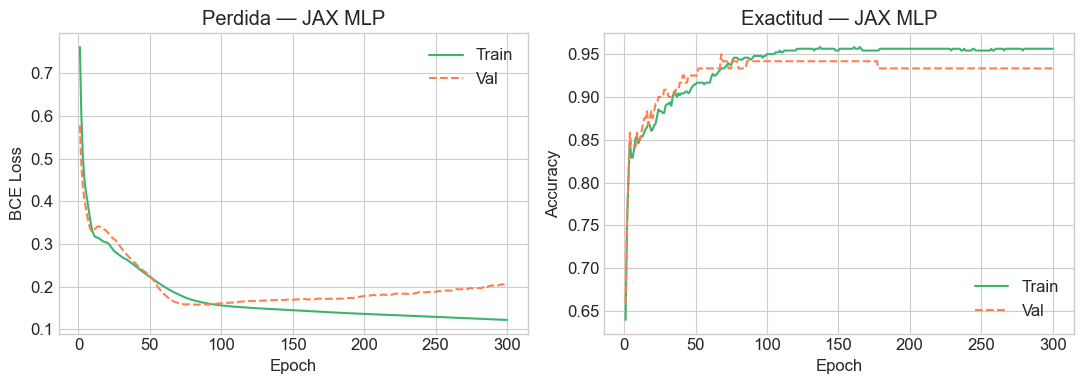

In [77]:
# Curvas de aprendizaje JAX
epochs = range(1, 301)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs, hist_jax["tr_loss"], label="Train", color="mediumseagreen")
ax1.plot(epochs, hist_jax["vl_loss"], label="Val",   color="coral", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("Perdida — JAX MLP")
ax1.legend()

ax2.plot(epochs, hist_jax["tr_acc"], label="Train", color="mediumseagreen")
ax2.plot(epochs, hist_jax["vl_acc"], label="Val",   color="coral", linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Exactitud — JAX MLP")
ax2.legend()

plt.tight_layout()
plt.show()

---
## Parte 3 — Comparativa

### Curvas de convergencia: PyTorch vs JAX

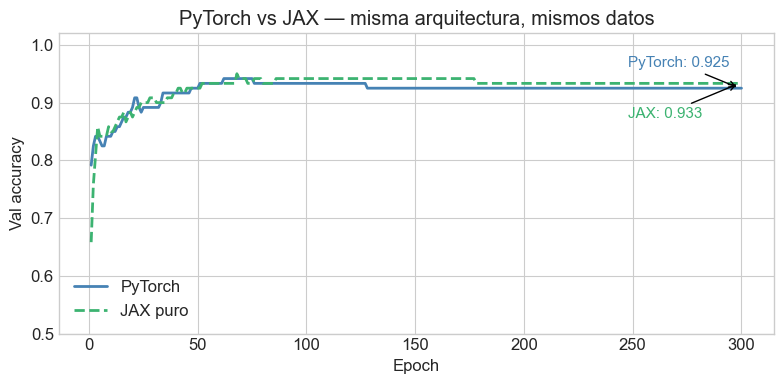

In [78]:
epochs = range(1, 301)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, hist_pt["vl_acc"],  label="PyTorch",  color="steelblue",      linewidth=2)
ax.plot(epochs, hist_jax["vl_acc"], label="JAX puro", color="mediumseagreen", linewidth=2, linestyle="--")

pt_final  = hist_pt["vl_acc"][-1]
jax_final = hist_jax["vl_acc"][-1]
ax.annotate(f"PyTorch: {pt_final:.3f}",  xy=(299, pt_final),
            xytext=(-80, 15), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), color="steelblue", fontsize=11)
ax.annotate(f"JAX: {jax_final:.3f}",     xy=(299, jax_final),
            xytext=(-80, -25), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), color="mediumseagreen", fontsize=11)

ax.set_xlabel("Epoch")
ax.set_ylabel("Val accuracy")
ax.set_title("PyTorch vs JAX — misma arquitectura, mismos datos")
ax.legend()
ax.set_ylim(0.5, 1.02)
plt.tight_layout()
plt.show()

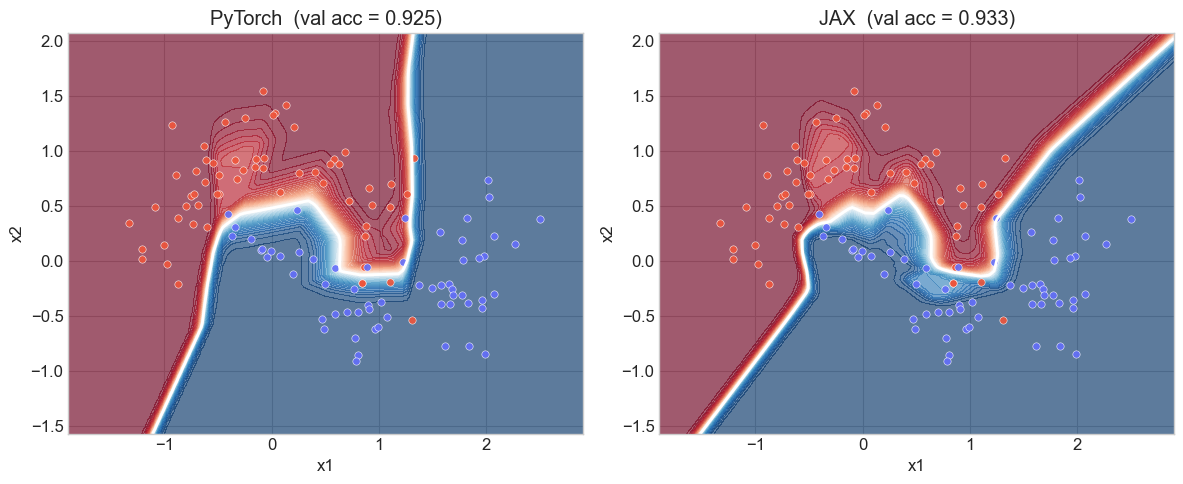

In [79]:
# Fronteras de decision lado a lado
h = 0.04
x0_min, x0_max = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
x1_min, x1_max = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))
grid_np = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

# PyTorch
with torch.no_grad():
    modelo.eval()
    prob_pt = torch.sigmoid(modelo(torch.tensor(grid_np))).numpy().reshape(xx.shape)

# JAX
prob_jax = jax.device_get(
    forward(params, jnp.array(grid_np))
).reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, prob, titulo, acc in [
    (ax1, prob_pt,  "PyTorch", pt_final),
    (ax2, prob_jax, "JAX",     jax_final)
]:
    ax.contourf(xx, yy, prob, levels=50, cmap="RdBu", alpha=0.65)
    ax.contour( xx, yy, prob, levels=[0.5], colors="white", linewidths=2)
    for cls, color in [(0, "#EF553B"), (1, "#636EFA")]:
        mask = y_val == cls
        ax.scatter(X_val[mask, 0], X_val[mask, 1],
                   c=color, edgecolors="white", linewidths=0.4, s=28, alpha=0.9)
    ax.set_title(f"{titulo}  (val acc = {acc:.3f})")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

---
## Parte 4 — Ejercicios adicionales

Completa los siguientes ejercicios si terminaste antes o como tarea.

### Ejercicio 1: Efecto de la tasa de aprendizaje

Entrena el MLP de PyTorch con `lr = 0.001`, `lr = 0.01` y `lr = 0.1`.  
Grafica las tres curvas de `val_loss` en la misma figura.  
¿Que observas?

In [ ]:
# TODO: Ejercicio 1 — efecto de la tasa de aprendizaje
learning_rates = [0.001, 0.01, 0.1]
colores        = ["steelblue", "mediumseagreen", "tomato"]

fig, ax = plt.subplots(figsize=(8, 4))

for lr, color in zip(learning_rates, colores):
    # TODO: entrenar modelo con esta lr y graficar vl_loss
    pass

ax.set_xlabel("Epoch")
ax.set_ylabel("Val loss")
ax.set_title("Efecto de la tasa de aprendizaje")
ax.legend()
plt.tight_layout()
plt.show()

### Ejercicio 2: Dropout en PyTorch

Modifica la clase `MLP` para agregar `nn.Dropout(p=0.3)` despues de cada capa ReLU.  
Reentrena y compara las curvas train vs val con y sin dropout.  
¿Cambia la brecha entre entrenamiento y validacion?

In [ ]:
# TODO: Ejercicio 2 — Dropout
class MLPConDropout(nn.Module):
    def __init__(self, p=0.3):
        super().__init__()
        self.red = nn.Sequential(
            # TODO: mismo que MLP pero con nn.Dropout(p) despues de cada ReLU
        )

    def forward(self, x):
        return self.red(x)

### Ejercicio 3: make_circles en lugar de make_moons

Reemplaza el dataset con `make_circles(n_samples=600, noise=0.1, factor=0.5, random_state=42)`.  
¿El modelo aprende correctamente? ¿Cambia la forma de la frontera de decision?

In [ ]:
# TODO: Ejercicio 3 — make_circles
from sklearn.datasets import make_circles
# X_c, y_c = make_circles(...)
# ... reentrenar y visualizar

### Ejercicio 4 (Bonus JAX): Derivadas de orden superior

JAX permite componer `jax.grad` para obtener derivadas de cualquier orden.  
Calcula la primera y segunda derivada de la perdida BCE respecto a un peso escalar `w`,  
con `x = 1.0` e `y = 1.0` fijos, para valores de `w` en el rango `[-4, 4]`.  
Graficalas en una figura de 2 subplots.

In [ ]:
# TODO: Ejercicio 4 — derivadas de orden superior con JAX
def bce_escalar(w):
    sigma = jax.nn.sigmoid(w)
    return -jnp.log(jnp.clip(sigma, 1e-7, 1.0 - 1e-7))

# grad1 = jax.grad(bce_escalar)
# grad2 = jax.grad(jax.grad(bce_escalar))
# ...
# Graficar bce_escalar, grad1 y grad2 en funcion de w

---

## Resumen

| | PyTorch | JAX |
|---|---|---|
| Definicion del modelo | `class MLP(nn.Module)` | Funcion `forward(params, x)` |
| Parametros | Internos al objeto | Diccionario externo |
| Gradientes | `loss.backward()` | `jax.value_and_grad(bce)(params, x, y)` |
| Paso de entrenamiento | `opt.step()` | `optax.apply_updates(params, updates)` |
| Compilacion | Eager | `@jax.jit` |
| Aleatoriedad | `torch.manual_seed(42)` | `jax.random.PRNGKey(42)` |

**Ambos frameworks** producen modelos equivalentes para la misma arquitectura y los mismos hiperparametros. La diferencia es el paradigma de programacion, no la capacidad del modelo.

---
*Mineria de Datos · Facultad de Ciencias, UNAM · Diego Villalba*